<a href="https://colab.research.google.com/github/jdasam/aat3020/blob/2026/NLP_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3

In this assignment, you will **build a personalized text generator** using language model fine-tuning.

- **Problem 1 (10 pts)**: Implement an LSTM cell from scratch.
- **Problem 2 (15 pts)**: Choose a creative corpus, fine-tune GPT-2 with two methods (Full and LoRA), and compare.
- **Problem 3 (15 pts)**: Generate your best creative output and submit a reflection report.

**Submission files**

| File | Contents |
|---|---|
| `NLP_Assignment_3_{student_id}.py` | Problem 1 implementation |
| `NLP_Assignment_3_{student_id}.ipynb` | Full notebook with all outputs |
| `corpus.txt` | Your preprocessed corpus |
| `report.pdf` | Problem 3-2 report (1–2 pages) |

In [2]:
!pip install -q transformers datasets "peft>=0.10.0" "torchao>=0.16.0"
!wget -q https://raw.githubusercontent.com/jdasam/aat3020/2026/NLP_Assignment_3.py
!wget -q https://raw.githubusercontent.com/jdasam/aat3020/2026/assignment3_pre_defined.py

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from assignment3_pre_defined import (
    create_gpt2_dataset, get_lora_model, count_trainable_params,
    plot_loss_curves, generate_text
)

## Problem 1: LSTM Implementation (10 pts)

Implement an LSTM using only `nn.Linear`, `torch.sigmoid`, and `torch.tanh`.

$$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$$
$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$
$$\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$$
$$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$$
$$c_t = f_t \otimes c_{t-1} + i_t \otimes \tilde{c}_t$$
$$h_t = o_t \otimes \tanh(c_t)$$

**Implementation constraint**: Keep the weight concatenation order as `[i | f | g | o]` to match PyTorch's `nn.LSTM` convention (required for Test 4).

In [4]:
class MyLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        '''
        TODO: Define the weights and biases for a single-layer, uni-directional LSTM.

        Arguments:
          input_size  (int): Dimensionality of input x. Denoted as `d` in the equations above.
          hidden_size (int): Dimensionality of hidden state h. Denoted as `h` in the equations above.

        Module definitions:
          self.weight_ih (nn.Linear): Combines [W_i | W_f | W_c | W_o] with bias.
                                       in_features=input_size, out_features=4*hidden_size
          self.weight_hh (nn.Linear): Combines [U_i | U_f | U_c | U_o] with bias.
                                       in_features=hidden_size, out_features=4*hidden_size

        Note: Weight order must follow PyTorch's official LSTM convention: [i | f | g | o].
        '''
        self.weight_ih = nn.Linear(in_features=input_size, out_features=4*hidden_size, bias=True)
        self.weight_hh = nn.Linear(in_features=hidden_size, out_features=4*hidden_size, bias=True)
        self.hidden_size = hidden_size

    def _cal_single_step(self, x_t, last_hidden, last_cell):
        '''
        Args:
          x_t         : [B, input_size]
          last_hidden : [B, hidden_size]
          last_cell   : [B, hidden_size]
        Returns:
          updated_hidden, updated_cell --- each [B, hidden_size]

        TODO: Implement the LSTM equations above.
        Hint: self.weight_ih(x_t) + self.weight_hh(last_hidden) gives [B, 4*hidden_size]
              in the order [i_gate | f_gate | g | o_gate].
        '''
        assert x_t.ndim == last_hidden.ndim == last_cell.ndim == 2
        H = self.hidden_size
        # Write your code here
        gates = self.weight_ih(x_t) + self.weight_hh(last_hidden)  # [B, 4H]
        i_gate, f_gate, g_gate, o_gate = gates.split(H, dim=1)

        i_gate = torch.sigmoid(i_gate)
        f_gate = torch.sigmoid(f_gate)
        g_gate = torch.tanh(g_gate)
        o_gate = torch.sigmoid(o_gate)

        updated_cell = f_gate * last_cell + i_gate * g_gate
        updated_hidden = o_gate * torch.tanh(updated_cell)
        return updated_hidden, updated_cell

    def forward(self, x, hidden_and_cell_state=None):
        '''
        Args:
          x                     : [B, T, input_size]
          hidden_and_cell_state (optional): (h, c) each [B, hidden_size]
        Returns:
          output                : [B, T, hidden_size]
          (last_hidden, last_cell)
        TODO: Use a for loop to call _cal_single_step T times and assemble the output.
        '''
        if hidden_and_cell_state is not None and isinstance(hidden_and_cell_state, tuple):
            last_hidden, last_cell = hidden_and_cell_state
        else:
            last_hidden = torch.zeros(x.shape[0], self.hidden_size, device=x.device)
            last_cell   = torch.zeros(x.shape[0], self.hidden_size, device=x.device)

        # Write your code here
        B, T, _ = x.shape
        outputs = []
        for t in range(T):
            x_t = x[:, t, :]
            last_hidden, last_cell = self._cal_single_step(x_t, last_hidden, last_cell)
            outputs.append(last_hidden)

        output = torch.stack(outputs, dim=1)  # [B, T, hidden_size]
        return output, (last_hidden, last_cell)

In [5]:
# Test 1: _cal_single_step output shape check
input_size, hidden_size = 5, 17
model = MyLSTM(input_size, hidden_size)
B = 3
x_t = torch.randn(B, input_size)
h   = torch.zeros(B, hidden_size)
c   = torch.zeros(B, hidden_size)
h_new, c_new = model._cal_single_step(x_t, h, c)
assert h_new.shape == (B, hidden_size), f"expected ({B}, {hidden_size}), got {h_new.shape}"
assert c_new.shape == (B, hidden_size)
print("Test 1 passed ✓")

Test 1 passed ✓


In [6]:
# Test 2: forward output shape check
input_size, hidden_size = 16, 32
model = MyLSTM(input_size, hidden_size)
B, T = 8, 20
dummy = torch.randn(B, T, input_size)
output, (h_last, c_last) = model(dummy)
assert output.shape == (B, T, hidden_size), f"got {output.shape}"
assert h_last.shape == (B, hidden_size)
print("Test 2 passed ✓")

Test 2 passed ✓


In [7]:
# Test 3: check that full-sequence output matches step-by-step for-loop output
total_out, _ = model(dummy)
hc = (torch.zeros(B, hidden_size), torch.zeros(B, hidden_size))
for i in range(T):
    step_out, hc = model(dummy[:, i:i+1], hc)
assert (total_out[:, -1:] == step_out).all(), "for-loop output must match full-sequence output"
print("Test 3 passed ✓")

Test 3 passed ✓


In [8]:
# Test 4: numerical comparison with PyTorch's official LSTM
lstm_ref = nn.LSTM(input_size, hidden_size, batch_first=True)
lstm_ref.weight_ih_l0.data = model.weight_ih.weight.data
lstm_ref.bias_ih_l0.data   = model.weight_ih.bias.data
lstm_ref.weight_hh_l0.data = model.weight_hh.weight.data
lstm_ref.bias_hh_l0.data   = model.weight_hh.bias.data

out_mine, _ = model(dummy)
out_ref,  _ = lstm_ref(dummy)
assert torch.allclose(out_mine, out_ref, atol=1e-6), \
    f"max error: {(out_mine - out_ref).abs().max().item():.2e}"
print("Test 4 passed ✓  — output matches PyTorch's official LSTM implementation!")

Test 4 passed ✓  — output matches PyTorch's official LSTM implementation!


> **Note**: Run the cell below only after all Tests 1–4 pass.
>
> **How to edit the `.py` file in Colab**: In the left file browser (📁 icon), **double-click** `NLP_Assignment_3.py` → paste your code in the editor and save.

In [9]:
# Copy your Problem 1 implementation into NLP_Assignment_3.py, then run this cell to verify.
!python3 NLP_Assignment_3.py

  File "/content/NLP_Assignment_3.py", line 25
    self.weight_ih = nn.Linear(in_features=, out_features=, bias=True) # TODO: complete this layer by selecting proper in_features and out_features
                               ^^^^^^^^^^^^
SyntaxError: expected argument value expression


## Problem 2: Fine-tuning GPT-2 — Full vs LoRA (15 pts)

- **2-1**: Set a creative goal, choose a corpus, and preprocess it
- **2-2**: Fine-tune GPT-2 with Full fine-tuning and LoRA — compare parameter counts and loss curves
- **2-3**: Compare both models on the same prompts


> **Before you set a goal: GPT-2 is not ChatGPT.**
>
> You are probably used to large instruction-tuned models (ChatGPT, Claude,
> Gemini). GPT-2 medium is a 355M-parameter base model from 2019, and you are
> giving it a light fine-tune on a small corpus. It behaves very differently,
> and your goal has to respect that.
>
> | | Modern instruction LLM | GPT-2 medium, lightly fine-tuned |
> |---|---|---|
> | How you steer it | **Instructions** ("write a noir poem about loss") | A **prefix** it continues; it cannot follow instructions |
> | What fine-tuning buys you | Little, it is already general | A shift toward your corpus's **surface texture**: diction, rhythm, format |
> | "Mix style A with style B" | Yes, on request | No. Only what is statistically in the corpus, often as accidental blur |
> | Q&A / dialogue / persona | Yes | No. It produces continuations, not answers |
> | Staying on topic | Pages | Roughly 1 to 3 sentences, then it drifts, repeats, or loops |
> | Facts | Mostly reliable | Unreliable. It confabulates freely |
>
> **The practical consequence:** you are not commissioning a finished result.
> You are biasing a generator toward a texture, then sampling many times and
> keeping the good accidents. The creative work lives in two places the model
> does not touch: which corpus you feed it, and which outputs you choose to
> frame. Set your goal around a *voice you can recognize in 1 to 2 sentences of
> output*, not around a task you would hand to ChatGPT.


In [10]:
assert torch.cuda.is_available(), (
    "GPU is not enabled.\n"
    "Go to: [Runtime] → [Change runtime type] → select [GPU], then restart the session."
)
device = 'cuda'
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


In [11]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
print(f"Vocab size: {len(tokenizer)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Vocab size: 50257


### Problem 2-1: Creative Goal + Corpus + Preprocessing

> You write up your creative goal and corpus choice in the **Problem 3-2 report**, not in this notebook. The steps below help you decide them.

#### Step 1. Define your creative goal (1 to 2 sentences)

Your creative goal is a description of the **voice** you want the fine-tuned
model to speak in. Keep in mind what this model can and cannot do: GPT-2 is a
small 2019 model, so a short fine-tune teaches it the *surface texture* of your
corpus (vocabulary, tone, rhythm, sentence shape, recurring motifs, formatting)
but not facts or long, coherent plots. Aim your goal at that texture, not at
"a correct story."

A strong goal answers three questions:

1. **Voice.** Whose language is it, in what register, in what genre? The more
   specific, the better.
2. **Concept.** What do you want this text-machine to be or to do, and why is
   that interesting? This is the part that turns a homework exercise into a piece.
3. **Recognition.** If it works, what will you see in the output? Name 2 to 3
   concrete signals: a vocabulary, a syntactic tic, a tone, a formatting pattern.
   You will reuse these exact signals in your Problem 3-2 report.

Avoid goals GPT-2 cannot reach: factual accuracy, a coherent multi-page
narrative, or anything that needs the model to *understand* rather than *imitate*.

**Directions that fit a small continuation model** (starting points, not a menu to copy):

- **Reanimating a dead vernacular.** Fine-tune on a stylistically uniform body
  of period text (1920s classifieds, mid-century ad copy, early-2000s forum
  posts). Prime it with a short opening and let it continue. This is the single
  most reliable use of GPT-2: it copies a consistent surface voice well.

- **A genre at full saturation.** Pick a genre with heavy surface markers (noir,
  SCP Foundation entries, horoscopes, recipe blogs, patch notes). The strong
  formatting and diction are exactly what a light fine-tune captures, so outputs
  read as near-parody of the form.

- **Ventriloquism, not interview.** Build the corpus from one writer's prose
  (essays, letters, a single author's novels). You cannot ask it questions; it
  does not answer, it continues. Feed it the first half of a sentence in that
  voice and read what it completes. The piece is the uncanny continuation.

- **A soft formal constraint.** Curate a corpus where every line obeys one rule
  (all questions, all second person, all under six words). The model leans hard
  toward the constraint, though it breaks it sometimes. Those breaks are texture.

- **Statistical interference.** Train on two corpora at once and harvest the
  muddle. Do not expect controlled fusion: GPT-2 oscillates between the two
  voices and occasionally blurs them mid-sentence. If your goal is the glitch at
  the boundary rather than a clean blend, this works.

- **Autocomplete as a co-writer.** Treat the model as a stylistic autocomplete:
  you write a line, it offers a continuation in the corpus voice, you take or
  reject it, you write the next. The artifact is the human-machine duet, and it
  sidesteps GPT-2's weakness at staying coherent on its own.

#### Step 2. Choose a corpus that fits the goal (100 KB to 1 MB recommended)

Stylistic consistency matters more than raw size. A clean 200 KB corpus in a
single voice will beat a noisy 1 MB grab-bag. Likely sources: Project Gutenberg,
lyric or subtitle archives, public-domain transcripts, scraped blog posts, or
your own writing.

#### Step 3. Explain your corpus choice (1 to 2 sentences)

Tie it back to the voice you described in Step 1.

In [12]:
# --- Download or upload your raw corpus ---
# Option A: from a URL (uncomment and replace)
# !wget -O raw_corpus.txt "YOUR_URL_HERE"
#
# Option B: upload via the Colab file browser, then set the path below
RAW_CORPUS_PATH = 'raw_corpus.txt'

with open(RAW_CORPUS_PATH, 'r', encoding='utf-8') as f:
    raw_text = f.read()

print(f"Raw corpus size: {len(raw_text):,} characters")
print(f"\n=== First 500 chars ===")
print(repr(raw_text[:500]))

Raw corpus size: 798,664 characters

=== First 500 chars ===
"CITIES IN TNE SKY: YOUR CHILDREN \nWILL LIVE IN THEM , \n\nBE A PANELING PRO: TRACES, \n\nOF EXPERTS’ SECRETjS \n\n19 GREAT GADGETS 5'''“' \n\nFOR STEREO SWITCHING ^ - \n\nBUILD A 762-MM TELE \n\n\n\n12 DANDY U \nOUTBQAR \n\n\n\n\n\n\n\n\n\n\n\n\n\n70 'Oo^rrsdn \n\n\n\nloop-Charged 70.3 \nMore getaways | \nper gallon. \n\nPulling the great escape has to be one of \nthe best parts of boating. And our 70 hp \nLooper makes it even better. Because it \ndoesn't take much gas to island hop away \nfrom the crowd: \n\nLoop'C barging is one way we"


In [13]:
import re
def preprocess_corpus(raw_text: str) -> str:
    # TODO: Clean the raw corpus for language model training.
    # Common issues to handle:
    #   - Single \n within a sentence — replace with a space
    #   - Double \n\n (paragraph breaks) — keep or collapse
    #   - Boilerplate headers/footers — strip them
    #   - Repeated whitespace — normaliz
    text = raw_text

    # 1. 줄바꿈 통일
    text = text.replace('\r\n', '\n').replace('\r', '\n')

    # 2. 문단 구분 보존, 문장 내 줄바꿈은 공백으로
    text = re.sub(r'\n{2,}', '<PARA>', text)
    text = text.replace('\n', ' ')
    text = text.replace('<PARA>', '\n\n')
    text = re.sub(r'[ \t]+', ' ', text)

    paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]

    # 3. 표지/목차 잡음 제거 (짧고 대문자 비율 높은 줄)
    def is_cover_junk(p):
        if len(p) > 80:
            return False
        upper_ratio = sum(c.isupper() for c in p if c.isalpha()) / max(sum(c.isalpha() for c in p), 1)
        return upper_ratio > 0.6
    paragraphs = [p for p in paragraphs if len(p) >= 15 and not is_cover_junk(p)]

    # 4. 광고스러움 점수로 필터링
    AD_WORDS = ['new', 'now', 'free', 'save', 'best', 'introducing', 'great', 'guarantee',
                'only', 'today', 'world', 'first', 'amazing', 'revolutionary', 'discover',
                'quality', 'value', 'offer', 'price', 'buy', 'choose', 'available']

    def ad_score(p):
        score = p.count('$') * 3 + p.count('!') * 2
        score += len(re.findall(r'\byou\b|\byour\b', p, re.I)) * 1.5
        score += sum(p.lower().count(w) for w in AD_WORDS)
        if len(p) > 600:
            score -= 2
        return score

    scored = [(ad_score(p), p) for p in paragraphs]
    final_paras = [p for s, p in scored if s > 6]

    cleaned_text = '\n\n'.join(final_paras)
    return cleaned_text


cleaned_text = preprocess_corpus(raw_text)

print(f"Raw    : {len(raw_text):,} chars")
print(f"Cleaned: {len(cleaned_text):,} chars")
print(f"\n=== Before (chars 500–900) ===")
print(repr(raw_text[500:900]))
print(f"\n=== After  (chars 500–900) ===")
print(repr(cleaned_text[500:900]))

CORPUS_PATH = 'corpus.txt'
with open(CORPUS_PATH, 'w', encoding='utf-8') as f:
    f.write(cleaned_text)
print(f"\nSaved to '{CORPUS_PATH}'")

Raw    : 798,664 chars
Cleaned: 61,587 chars

=== Before (chars 500–900) ===
' get the most \nout of a gallon of gas. It brings in the new fuel \ncharge whife pushing out exhaust in one \ncontinuous power loop. \n\nOu r 70 hp sa ves gas i n other ways, too. \n\nExhaust tuning uses the energy of \nsound waves to clear exhaust gases \n\n\n\nfrom the combustion chamber. Then \npacks in a cleaner fuel/air mixture to \ndeliver more power on less gas. \n\nPatented Pressure- Back piston rings \nse'

=== After  (chars 500–900) ===
"ght ahead— at trolling speeds, or at any speed.\n\nWhen you sluft the other stem drives,, you do it w'ith muscle. When you shift ours, you do it with power. Just move the control as smoothly and easily as the iiutojnatie shift lever in your automo- bile. And it takes only u 22® movement of OMC's shift lever to go into forward or re- verse . The others take 40® to 45“ — which means slower response.\n\n"

Saved to 'corpus.txt'


In [14]:
gpt2_dataset = create_gpt2_dataset(CORPUS_PATH, tokenizer, block_size=128)
print(f"Training samples : {len(gpt2_dataset)}")
print(f"Sample length    : {len(gpt2_dataset[0]['input_ids'])} tokens")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (18674 > 1024). Running this sequence through the model will result in indexing errors


Training samples : 290
Sample length    : 128 tokens


### Problem 2-2: Full Fine-tuning + LoRA (5 pts)

We train GPT-2 twice on the same corpus.

- **Full fine-tuning**: updates all 355M parameters
- **LoRA**: adds small low-rank adapter matrices and freezes the rest (∼0.3% trainable)

Run both cells below, then compare the parameter counts and loss curves.

In [15]:
from transformers import GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling

gpt2_full = GPT2LMHeadModel.from_pretrained("gpt2-medium").to(device)
print("=== Full fine-tuning ===")
count_trainable_params(gpt2_full)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args_full = TrainingArguments(
    output_dir="./gpt2_full",
    max_steps=500,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
)

trainer_full = Trainer(
    model=gpt2_full,
    args=training_args_full,
    train_dataset=gpt2_dataset,
    data_collator=data_collator,
)
print("Starting Full fine-tuning...")
trainer_full.train()
full_losses = [x['loss'] for x in trainer_full.state.log_history if 'loss' in x]
print("Done!")

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

=== Full fine-tuning ===
학습 파라미터: 354,823,168 / 전체: 354,823,168  (100.00%)
Starting Full fine-tuning...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,5.919571
20,5.497922
30,5.676596
40,5.510441
50,5.269590
60,5.543521
70,5.423706
80,4.987823
90,4.946268
100,5.130609


Done!


In [16]:
from transformers import GPT2LMHeadModel

gpt2_lora = get_lora_model(GPT2LMHeadModel.from_pretrained("gpt2-medium")).to(device)
print("=== LoRA fine-tuning ===")
count_trainable_params(gpt2_lora)

training_args_lora = TrainingArguments(
    output_dir="./gpt2_lora",
    max_steps=1500,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=3e-4,
    weight_decay=0.01,
    fp16=True,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
)

trainer_lora = Trainer(
    model=gpt2_lora,
    args=training_args_lora,
    train_dataset=gpt2_dataset,
    data_collator=data_collator,
)
print("Starting LoRA fine-tuning...")
trainer_lora.train()
lora_losses = [x['loss'] for x in trainer_lora.state.log_history if 'loss' in x]
print("Done!")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


=== LoRA fine-tuning ===
학습 파라미터: 6,291,456 / 전체: 361,114,624  (1.74%)
Starting LoRA fine-tuning...


Step,Training Loss
10,5.941700
20,5.526988
30,5.718151
40,5.541559
50,5.311343
60,5.592228
70,5.490270
80,5.127579
90,5.052205
100,5.282909


Done!


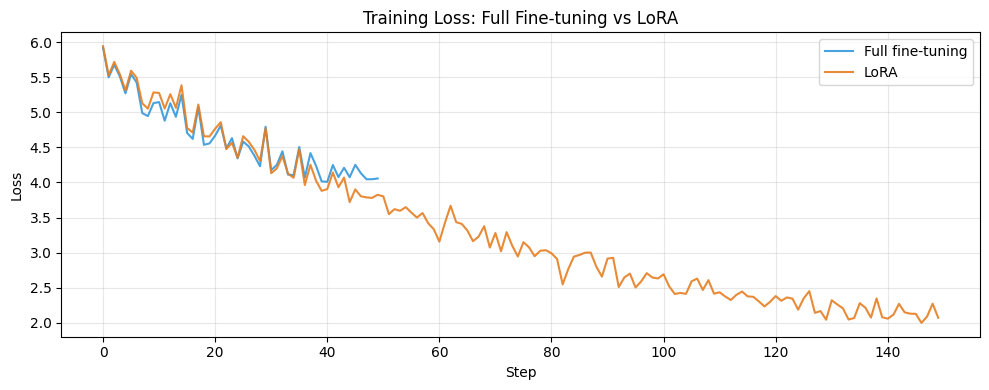

In [17]:
plot_loss_curves(full_losses, lora_losses)

### Problem 2-3: Compare Outputs

Design **3 or more prompts** that fit the theme of your corpus.
Run the cell below to see outputs from both models side by side.

In [18]:
NUM_SAMPLES = 3  # number of generations per prompt
SEED = None      # set an int (e.g. 42) for reproducible, fair Full-vs-LoRA comparison, or None for fresh samples

prompts = [
    "Introducing the all-new",
    "Save up to",
    "For the first time ever, you can",
]

for prompt in prompts:
    print(f"\n{'='*60}")
    print(f"Prompt: {prompt!r}")
    print(f"{'='*60}")
    full_outs = generate_text(gpt2_full, tokenizer, prompt, max_new_tokens=80, temperature=0.9, num_samples=NUM_SAMPLES, seed=SEED)
    lora_outs = generate_text(gpt2_lora, tokenizer, prompt, max_new_tokens=80, temperature=0.9, num_samples=NUM_SAMPLES, seed=SEED)
    for i, (f, l) in enumerate(zip(full_outs, lora_outs)):
        print(f"\n  [Full #{i+1}] {f}")
        print(f"\n  [LoRA  #{i+1}] {l}")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Prompt: 'Introducing the all-new'

  [Full #1] Introducing the all-new MSAVE! Auto Store!  "This is the most exciting time in my life!! I am so ready for this new retail career and I can't wait to let you know how much I love my new job.  I plan to give the whole world the inside story on what I do. As you know, our job is to hear from makers and tell the whole story through our pictures

  [LoRA  #1] Introducing the all-new SR5 in the new R5.0 series. These 40-page bound volumes offer more information and help you pick the right car for the kind of driving you want. Get more information right from the experts at AUTO LEFT . . .  With new auto repair school and information from AutoNation, Pontiac's Knowledge Base and AutoLite'jran, Pontiac has never been

  [Full #2] Introducing the all-new, full-color, full-page, full-colour Hardback edition of the best-selling '90s classic, "We'd Like to Buy You a New Car. If You Ask Us." Now you can get behind the wheel of a car that's had mileage

### Problem 3-1: Best Creative Output

You have two trained models and a goal. This step is not "press generate once
and hope." With a small continuation model, **the creative act is curation**:
you generate many candidates and choose. Think of it like photography. You shoot
many frames and keep a few.

**Step 1. Choose a model, with evidence.**
Look back at your Problem 2-3 outputs. Which model hit the Recognition signals
you named in 2-1 *more often*? Decide on that basis, not on one lucky sample.

**Step 2. Generate in batches and judge against your goal.**
A single sample tells you almost nothing, because this model varies wildly run
to run. Raise `num_samples` (try 10 to 20), generate, then hold your 2-1
Recognition signals next to the outputs. The question is not "is this good
writing," it is "does this hit the 2 to 3 signals I set."

**Step 3. Turn the knobs with intent.** Each one does something specific to a
model like this:
- `temperature`: low (~0.7) stays close to the corpus but repeats itself; high
  (~1.1 to 1.2) is more inventive but slides into nonsense. Your
  recognizable-but-alive sweet spot is usually in between. Find it by ear.
- `max_new_tokens`: this model holds a voice for only a sentence or three before
  it drifts, loops, or repeats. For a clean artifact, keep it short. If the
  breakdown itself is interesting, let it run long and treat the collapse as part
  of the work.
- `prompt`: the prefix sets the register. A prompt already written in your
  corpus's voice pulls the model into that voice faster than a neutral one.
  Prime it.

**Step 4. Curate and frame.**
Pick the one output (or a deliberate stitch of a few) that best embodies your
goal. That choice is your authorship. Keep a note of what you rejected and why.
You record your model choice, final output, and the exact settings that produced
it in the report.

In [19]:
# Pick your model
best_model = gpt2_full     # Full fine-tuning
# best_model = gpt2_lora   # LoRA

# Generate a batch of candidates, then curate
final_prompt   = "Save up to"   # try priming in your corpus's voice
temperature    = 0.9                        # sweep 0.7 to 1.2
max_new_tokens = 80                         # short keeps the voice; long shows the drift
NUM_CANDIDATES = 12                         # generate many, choose one
seed           = None                       # set an int (e.g. 42) to reproduce a run, or None for fresh samples

candidates = generate_text(best_model, tokenizer, final_prompt,
                           max_new_tokens=max_new_tokens,
                           temperature=temperature,
                           num_samples=NUM_CANDIDATES,
                           seed=seed)
for i, c in enumerate(candidates):
    print(f"\n--- candidate #{i+1} ---\n{c}")

# After reading these, record your chosen output and the exact settings that
# produced it in your Problem 3-2 report.



--- candidate #1 ---
YOUR BEST PROMPT HERE : FREE STUFF!!  If you like the designs on this page, you should love the FREE STUFF!!  All you have to do is go to my new "home" page called "The Arts" at the top of this page.  If you like the photo below, send it to:   This page was first printed in U.S Pilotman , No. 75,

--- candidate #2 ---
YOUR BEST PROMPT HERE. TO ORDER, PLACE YOUR ADDRESS IN THE FOLLOWING BOX:   If you do not know what you are doing, see an arc therapist, a counsellor, a counsellor-at-large, or a professional counselor, I urge you to get professional help. They can show you the truth about your problems and guide you to achieve what you want. And

--- candidate #3 ---
YOUR BEST PROMPT HERE. YELL IHU T'OCHTT!  TO HEAR  "KQE'S a mbttiOtfTf, MOOKIFlS Tb^. TO IhTb^IH. LIFETIME SAViHTA! 1 PM to 1A5.  BEDROOM IN YOUR BED

--- candidate #4 ---
YOUR BEST PROMPT HERE. 1.75EUR TO DOUBLE You SAVE $15, BECome a $7 DUTY PATENT Filer.  I n the early days of the automobile, you put

### Problem 3-2: Reflection Report - Submit as PDF

**Length**: about 3 pages, much of which will be your own generated outputs. This
report is where the whole assignment comes together: your goal and Recognition
signals from 2-1, the Full vs LoRA comparison from 2-2 and 2-3, and the curated
final result from 3-1.

Write in prose, but back every claim with your actual generated text. Do not just
describe what the model produced; paste the real outputs and quote them directly.
Include as many full samples as you need to support each point, and label which
model and settings produced each one. The grader should be able to see your
evidence in the report itself, not have to take your word for it.

**A. Record.**
Collect everything a reader needs to verify your work:
- Your creative goal in one sentence, plus the 2 to 3 Recognition signals from 2-1
- Corpus: source and size, and one sentence on why it fits the goal
- The model used for Problem 3 (Full or LoRA), the final prompt, temperature,
  max_new_tokens, and seed
- Your final output, pasted in full

**B. Full vs LoRA.**
- The two trainable-parameter counts from 2-2, and roughly what percentage LoRA trains
- One or two sentences on how the loss curves differed and what that implies
- Which model you took into Problem 3, and why. Paste the actual 2-3 outputs from
  both models on at least one shared prompt, so the difference you are describing
  is visible side by side rather than only asserted.

**C. Did the model learn your voice?**
This is the heart of the report. Go through your Recognition signals one at a time.
For each signal, paste real generated samples and point to the exact words that
show it, or show it failing. Use as many full outputs as you need; this section
should be mostly your model's text with your analysis around it. Then step back and
separate what the model captured (surface texture: diction, rhythm, format) from
what it did not (meaning, coherence, factual sense).

**D. Limits and what went wrong.**
Name one limitation you actually observed and paste the output where it appears:
topic drift, repetition or looping, confabulation, no controlled style mixing, or
ignoring instructions. Connect it to what GPT-2 is, a small 2019 continuation model
with no instruction tuning, not an LLM like ChatGPT. One paragraph of analysis
around the quoted example.